In [2]:
import pandas as pd

In [3]:
df = pd.read_csv("top_20_organizations_all_records.csv")

In [4]:
df.head()

,organization_name,project_type,hash,source_method_name,sink_method_name,source_repository_url,sink_repository_url,source_file_location,sink_file_location,source_query_project,violation,relational_id
0,Accenture,1,001f38391fcef54d171f006c0d41486a,_convert_scalar_indexer,NaN,https://github.com/Accenture/pandas/blob/maste...,NaN,./pandas/indexes/base.py:964,NaN,0,Observed Origin-no match found with SearchSECO...,20260407194623040908_ee56c2
1,Accenture,1,00294288937c6d1d3cb55ed18b0fc100,calculateAspectRatio,calculateAspectRatio,https://github.com/ionic-team/ionic-example-co...,https://github.com/Accenture/cordova-plugin-ca...,plugins/org.apache.cordova.camera/src/android/...,./src/android/CameraLauncher.java:988,5,Undetermined: Apache-2.0 with the Unknown (Pro...,20260407194623040871_0d76b5
2,Accenture,1,00821366cad6b5972b88c954a630dc8e,parseMboxLineByLine,parseMboxLineByLine,https://github.com/apache/mahout/blob/a41d378d...,https://github.com/Accenture/mahout/blob/maste...,integration/src/main/java/org/apache/mahout/ut...,./integration/src/main/java/org/apache/mahout/...,3,Custom incompatible with Apache-2.0,20260407194623039314_13964c
3,Accenture,1,0086eb94d7906ac04cc5e2a332b37227,transformMatch,transformMatch,https://github.com/apache/mahout/blob/482f7e06...,https://github.com/Accenture/mahout/blob/maste...,integration/src/main/java/org/apache/mahout/ut...,./integration/src/main/java/org/apache/mahout/...,3,Custom incompatible with Apache-2.0,20260407194623039314_13964c
4,Accenture,1,008af808e7d5f570d859874fcc1d3d33,writeToFileAtURL,NaN,https://github.com/Accenture/cordova-plugin-fi...,NaN,./src/android/LocalFilesystem.java:373,NaN,0,Observed Origin-no match found with SearchSECO...,20260407194623040984_2f2483


In [5]:
import numpy as np

# Assuming your initial dataframe is named 'df'

# 1. Determine your unique categories and target size
target_total = 2542
group_col = "source_query_project"
unique_groups = df[group_col].dropna().unique()
num_groups = len(unique_groups)

# 2. Calculate the base number of samples required per group
# e.g., 2542 // 6 groups = 423 rows each, with some remaining leftovers
base_samples_per_group = target_total // num_groups
remainder = target_total % num_groups

# 3. Build a target allocation map mapping {group_value: sample_size}
# This guarantees that the sum of samples adds up to EXACTLY 2,542
group_sizes = df[group_col].value_counts()
target_allocations = {}

# Distribute remainders to the first few groups to achieve exact sum
for i, group in enumerate(unique_groups):
    allocated = base_samples_per_group + (1 if i < remainder else 0)
    # Guard rail: Make sure we don't request more rows than the group actually has
    target_allocations[group] = min(allocated, group_sizes[group])

# 4. Execute the stratified sampling strategy safely
sampled_dfs = []
for group_val, size in target_allocations.items():
    group_subset = df[df[group_col] == group_val]
    sampled_subset = group_subset.sample(n=size, random_state=42)  # random_state for reproducibility
    sampled_dfs.append(sampled_subset)

# 5. Combine and shuffle the final sample collection
final_sampled_df = pd.concat(sampled_dfs).sample(frac=1, random_state=42).reset_index(drop=True)

# Verification check
print(f"Total rows sampled: {len(final_sampled_df)}")
print("\nDistribution per category:")
print(final_sampled_df[group_col].value_counts())

Total rows sampled: 2542

Distribution per category:
source_query_project
4    424
5    424
0    424
3    424
1    423
2    423
Name: count, dtype: int64


In [6]:
final_sampled_df.head()

,organization_name,project_type,hash,source_method_name,sink_method_name,source_repository_url,sink_repository_url,source_file_location,sink_file_location,source_query_project,violation,relational_id
0,Nokia,1,bb86a20bbdc77bc3984c8f1db5f63c51,swconfig_load_uci,swconfig_load_uci,https://github.com/Chadster766/McWRT/blob/203e...,https://github.com/nokia/openwrt/blob/master/p...,chaos_calmer/package/network/config/swconfig/s...,./package/network/config/swconfig/src/cli.c:209,4,High Risk - Unknown/Unlabeled source entering ...,20260407194623104614_a88d48
1,IBM,1,91761a7760902d834fb45e65df633ba8,getFp32ScaleData,getFp32ScaleData,https://github.com/ucb-bar/nvdla-sw/blob/2bb90...,https://github.com/IBM/mini-era/blob/master/sw...,./umd/core/src/compiler/engine-ast/ScaleOp.cpp...,./sw/umd/core/src/compiler/engine-ast/ScaleOp....,5,Undetermined: Unknown with the Custom (Provena...,20260407194622768706_708ccd
2,Nvidia,1,e37608ea1e6b7b13fe04ca8e1c0b1b5b,typeof_compute_fingerprint,typeof_compute_fingerprint,<undefined>/blob/f75c45a8dd7c7acfdfa8b41bea186...,https://github.com/NVIDIA/numba-cuda/blob/main...,numba/_typeof.c:457,./numba_cuda/numba/cuda/cext/_typeof.cpp:519,5,Undetermined: BSD-2-Clause with the Unknown (P...,20260407194622949711_b33a58
3,Microsoft,1,eb8adcea18eeb7d80d415989ff3a2cd7,arm_mat_mult_q31,arm_mat_mult_q31,https://github.com/SL-RU/stm32libs/blob/dbc5f9...,https://github.com/microsoft/uf2-samdx1/blob/m...,HAL/keyboard/keyboard/Drivers/CMSIS/DSP_Lib/So...,./lib/cmsis/CMSIS/DSP_Lib/Source/MatrixFunctio...,4,High Risk - Unknown/Unlabeled source entering ...,20260407194622378241_ab5217
4,Google,1,a508c2c316180d9ae74426622e0b334a,_isnull_ndarraylike_old,_isnull_ndarraylike_old,https://github.com/pyparallel/pyparallel/blob/...,https://github.com/google/pandas/blob/master/p...,Lib/site-packages/pandas-0.17.0-py3.3-win-amd6...,./pandas/core/common.py:303,5,Undetermined: Custom with the Custom (Provenan...,20260407194622623187_81e715


In [ ]:
final_sampled_df.to_csv("human_validation_set.csv", index=False)

In [4]:
final_sampled_df=pd.read_csv("human_validation_set.csv")

In [ ]:
def extract_licenses(violation_string):
    # Fallback values if the row doesn't match an incompatibility format
    source_lic, sink_lic = None, None

    # Cast to string to safeguard against any accidental NaN/float values
    v = str(violation_string)

    # 1. Clean the string if a colon exists (take everything after the first colon)
    if ":" in v:
        v = v.split(":", 1)[1].strip()

    # 2. Extract licenses using the "incompatible with" anchor
    if "incompatible with" in v:
        left, right = v.split("incompatible with", 1)
        sink_lic = left.strip()
        source_lic = right.strip()
    elif "compatible with" in v:
        left, right = v.split("compatible with", 1)
        sink_lic = left.strip()
        source_lic = right.strip()
    elif "same license" in v:
        left, right = v.split("same license", 1)
        sink_lic = right.strip()
        source_lic = right.strip()
    elif "with the" in v:
        left, right = v.split("with the", 1)
        sink_lic = left.strip().split(":")[0]
        source_lic = right.strip().split(" ")[0]

    # Return as a pandas Series so it splits cleanly into two columns
    return pd.Series([source_lic, sink_lic])


# Assuming your dataframe is named 'final_sampled_df' (or 'df')
# Apply the function across the rows
final_sampled_df[["source_license", "sink_license"]] = final_sampled_df[
    "violation"
].apply(extract_licenses)

# Preview the results to verify mapping
print(
    final_sampled_df[
        ["violation", "source_license", "sink_license"]
    ].head()
)

                                           violation source_license  \
0  High Risk - Unknown/Unlabeled source entering ...        Unknown   
1  Undetermined: Unknown with the Custom (Provena...         Custom   
2  Undetermined: BSD-2-Clause with the Unknown (P...        Unknown   
3  High Risk - Unknown/Unlabeled source entering ...        Unknown   
4  Undetermined: Custom with the Custom (Provenan...         Custom   

   sink_license  
0        Custom  
1       Unknown  
2  BSD-2-Clause  
3        Custom  
4        Custom  


In [23]:
final_sampled_df.to_csv("human_validation_set.csv", index=False)

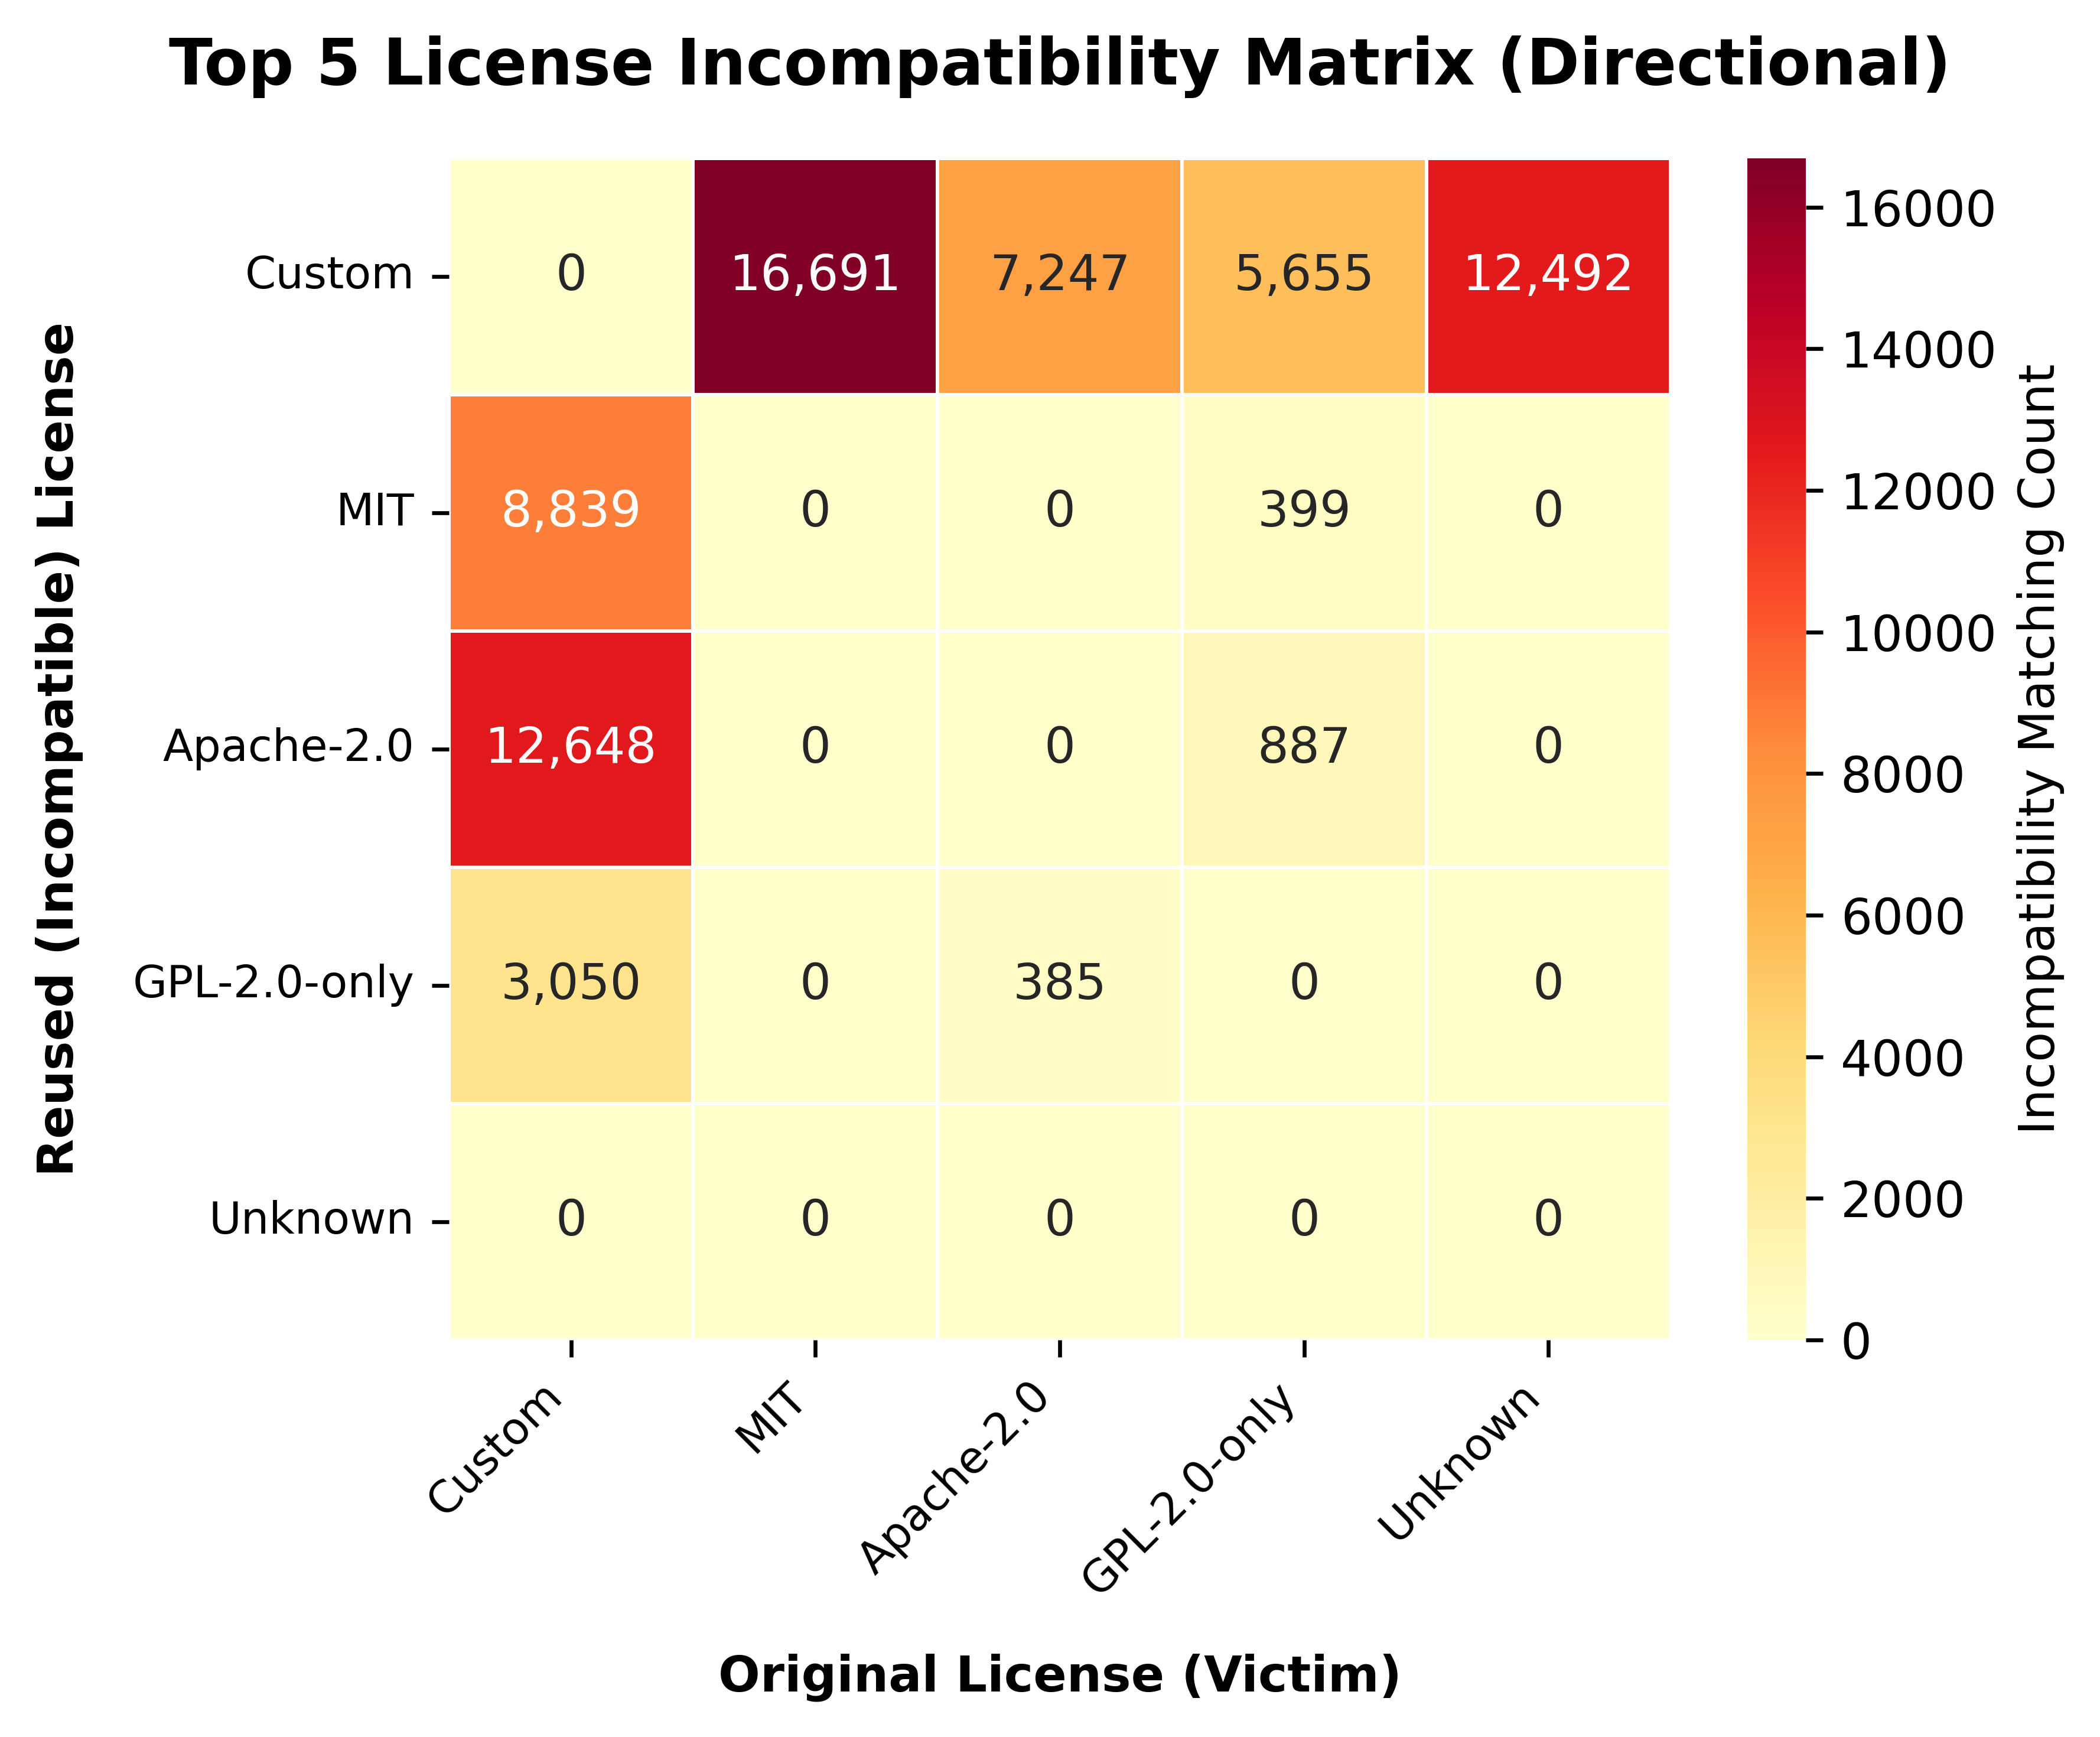

In [2]:
from collections import Counter
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns


def fetch_license_conflicts(csv_path="repository_data.csv"):
    """Loads violations directly from the CSV file replacing the SQL database context."""
    # Read only the required columns to conserve memory
    df = pd.read_csv(csv_path, usecols=["project_type", "violation"])

    # Mimic the SQL WHERE conditions using fast pandas vector operations
    filtered_df = df[
        (df["project_type"] == 1)
        & (df["violation"].notna())
        & (df["violation"] != "")
    ]

    # Convert the resulting pandas Series directly into a Python list
    violations = filtered_df["violation"].tolist()
    return violations


def build_license_matrix(violations, top_n=10):
    pair_counts = Counter()

    for v in violations:
        # 1. Clean the string if a colon exists (take everything after the first colon)
        if ":" in v:
            v = v.split(":", 1)[1].strip()

        # 2. Extract licenses using the "incompatible with" anchor string safely
        if "incompatible with" in v:
            left, right = v.split("incompatible with", 1)
            left = left.strip()
            right = right.strip()
            pair_counts[(left, right)] += 1  # Directional flow tracking

    # Count total participation per license
    license_counts = Counter()
    for (l1, l2), count in pair_counts.items():
        license_counts[l1] += count  # Active participation as violator
        license_counts[l2] += count  # Active participation as original victim

    top_licenses = [lic for lic, _ in license_counts.most_common(top_n)]

    # Build directional NxN matrix dataframe frame
    matrix = pd.DataFrame(0, index=top_licenses, columns=top_licenses)

    for (l1, l2), count in pair_counts.items():
        if l1 in top_licenses and l2 in top_licenses:
            matrix.loc[l1, l2] = count

    return matrix


def plot_license_heatmap(matrix):
    plt.figure(figsize=(6, 5), dpi=600)
    sns.heatmap(
        matrix,
        annot=True,
        fmt=",d",
        cmap="YlOrRd", # Beautiful multi-hue progression
        cbar=True,
        linewidths=0.5,
        cbar_kws={"label": "Incompatibility Matching Count"}
    )
    plt.title(
        "Top 5 License Incompatibility Matrix (Directional)",
        fontsize=13,
        pad=15,
        weight="bold",
    )
    plt.xlabel("Original License (Victim)", weight="bold", fontsize=10, labelpad=10)
    plt.ylabel("Reused (Incompatible) License", weight="bold", fontsize=10, labelpad=10)

    # Protect against overlapping axis labels
    plt.xticks(rotation=45, ha="right", fontsize=9)
    plt.yticks(rotation=0, fontsize=9)

    plt.tight_layout()
    plt.show()


if __name__ == "__main__":
    # Ensure your data filename matches this target path parameter string
    csv_file = "./top_20_organizations_all_records.csv"

    # Step 1: Run local extraction pipeline
    violations = fetch_license_conflicts(csv_file)

    # Step 2: Build the NxN relation matrix mapping dataframe
    matrix = build_license_matrix(violations, top_n=5)

    # Step 3: Persistence operations export
    matrix.to_csv("incompatibility_matrix.csv", index=True)

    # Step 4: Render visualization asset
    plot_license_heatmap(matrix)

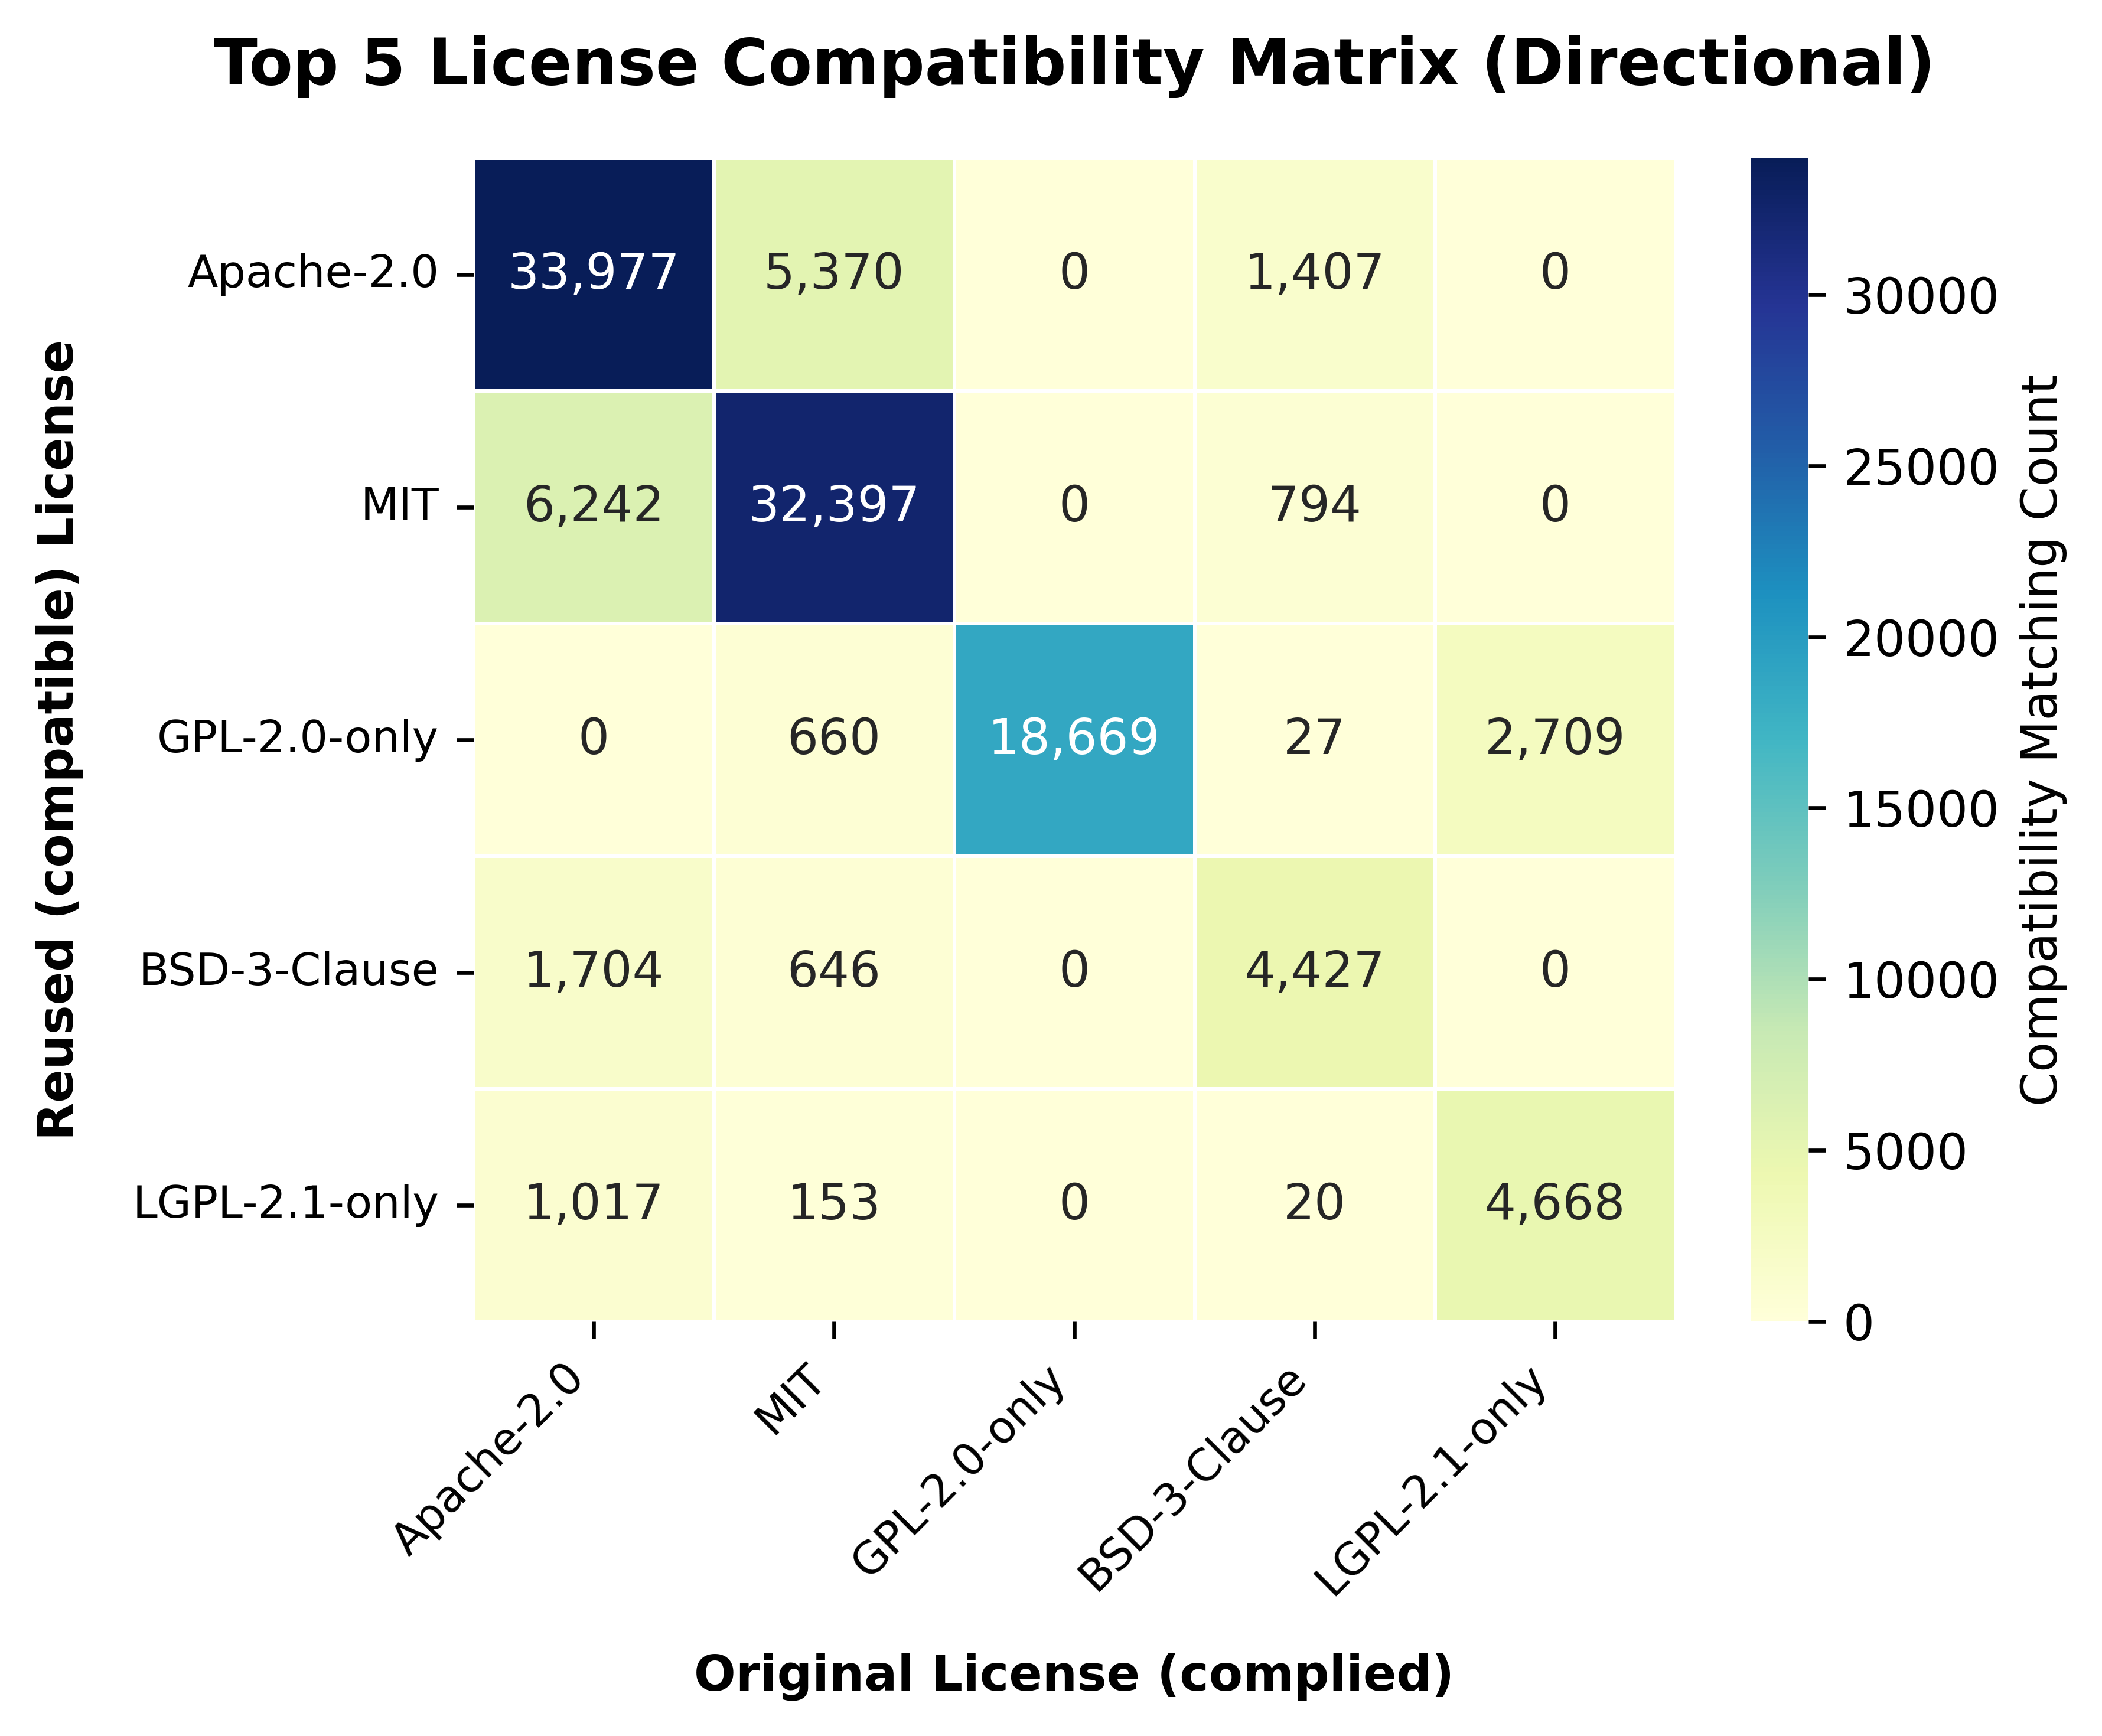

In [1]:
from collections import Counter
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns


def fetch_license_conflicts(csv_path="repository_data.csv"):
    """Loads violations directly from the CSV file instead of an SQL database."""
    # usecols keeps the memory footprint small by reading only what we filter/process
    df = pd.read_csv(csv_path, usecols=["project_type", "violation"])

    # Vector query replacing the SQL WHERE criteria
    filtered_df = df[
        (df["project_type"] == 1)
        & (df["violation"].notna())
        & (df["violation"] != "")
    ]

    return filtered_df["violation"].tolist()


def build_license_matrix(violations, top_n=10):
    pair_counts = Counter()

    for v in violations:
        # Standardize: strip out string description prefixes before a colon if they exist
        if ":" in v:
            v = v.split(":", 1)[1].strip()

        # Case 1: Handle explicit "compatible with" mappings
        if " compatible with" in v:
            left, right = v.split(" compatible with", 1)
            left = left.strip()
            right = right.strip()
            pair_counts[(left, right)] += 1  # directional

        # Case 2: Handle identical matching licenses ("Sink is following same license ...")
        elif "Sink is following same license " in v:
            # Extract the license string directly following the anchor phrase
            matched_license = v.split("Sink is following same license ", 1)[
                1
            ].strip()
            # Since they are the same license, both source and sink are identical
            pair_counts[(matched_license, matched_license)] += 1

    # Count total participation per license
    license_counts = Counter()
    for (l1, l2), count in pair_counts.items():
        license_counts[l1] += count  # as reused license
        license_counts[l2] += count  # as original license

    top_licenses = [lic for lic, _ in license_counts.most_common(top_n)]

    # Build directional NxN matrix
    matrix = pd.DataFrame(0, index=top_licenses, columns=top_licenses)

    for (l1, l2), count in pair_counts.items():
        if l1 in top_licenses and l2 in top_licenses:
            matrix.loc[l1, l2] = count  # keep direction only

    return matrix


def plot_license_heatmap(matrix):
    plt.figure(figsize=(6, 5), dpi=600)
    sns.heatmap(
        matrix,
        annot=True,
        fmt=",d",
        cmap="YlGnBu", # Beautiful multi-hue progression
        cbar=True,
        linewidths=0.5,
        cbar_kws={"label": "Compatibility Matching Count"}
    )
    plt.title(
        "Top 5 License Compatibility Matrix (Directional)",
        fontsize=13,
        pad=15,
        weight="bold",
    )
    plt.xlabel("Original License (complied)", weight="bold", fontsize=10, labelpad=10)
    plt.ylabel("Reused (compatible) License", weight="bold", fontsize=10, labelpad=10)

    # Protect against overlapping axis labels
    plt.xticks(rotation=45, ha="right", fontsize=9)
    plt.yticks(rotation=0, fontsize=9)

    plt.tight_layout()
    plt.show()


if __name__ == "__main__":
    csv_file = "./top_20_organizations_all_records.csv"

    # Run data parsing & matrix generation
    violations = fetch_license_conflicts(csv_file)
    matrix = build_license_matrix(violations, top_n=5)

    # Save output with row index names kept intact
    matrix.to_csv("compatibility_matrix.csv", index=True)

    # Render heatmap plot
    plot_license_heatmap(matrix)

In [12]:
import pandas as pd

# 1. Load the raw empirical dataset
# Replace 'raw_compliance_dataset.csv' with your actual input file name
df = pd.read_csv('top_20_organizations_all_records.csv')

In [13]:
df.head()

,organization_name,project_type,hash,source_method_name,sink_method_name,source_repository_url,sink_repository_url,source_file_location,sink_file_location,source_query_project,violation,relational_id
0,Accenture,1,001f38391fcef54d171f006c0d41486a,_convert_scalar_indexer,NaN,https://github.com/Accenture/pandas/blob/maste...,NaN,./pandas/indexes/base.py:964,NaN,0,Observed Origin-no match found with SearchSECO...,20260407194623040908_ee56c2
1,Accenture,1,00294288937c6d1d3cb55ed18b0fc100,calculateAspectRatio,calculateAspectRatio,https://github.com/ionic-team/ionic-example-co...,https://github.com/Accenture/cordova-plugin-ca...,plugins/org.apache.cordova.camera/src/android/...,./src/android/CameraLauncher.java:988,5,Undetermined: Apache-2.0 with the Unknown (Pro...,20260407194623040871_0d76b5
2,Accenture,1,00821366cad6b5972b88c954a630dc8e,parseMboxLineByLine,parseMboxLineByLine,https://github.com/apache/mahout/blob/a41d378d...,https://github.com/Accenture/mahout/blob/maste...,integration/src/main/java/org/apache/mahout/ut...,./integration/src/main/java/org/apache/mahout/...,3,Custom incompatible with Apache-2.0,20260407194623039314_13964c
3,Accenture,1,0086eb94d7906ac04cc5e2a332b37227,transformMatch,transformMatch,https://github.com/apache/mahout/blob/482f7e06...,https://github.com/Accenture/mahout/blob/maste...,integration/src/main/java/org/apache/mahout/ut...,./integration/src/main/java/org/apache/mahout/...,3,Custom incompatible with Apache-2.0,20260407194623039314_13964c
4,Accenture,1,008af808e7d5f570d859874fcc1d3d33,writeToFileAtURL,NaN,https://github.com/Accenture/cordova-plugin-fi...,NaN,./src/android/LocalFilesystem.java:373,NaN,0,Observed Origin-no match found with SearchSECO...,20260407194623040984_2f2483


In [14]:
# 3. Filter the dataframe to isolate these features
empirical_df = df.drop(columns=["project_type","relational_id"])
empirical_df = empirical_df.dropna(subset=['source_repository_url', 'sink_repository_url', 'source_file_location'], how='any')

In [39]:
url_length_mask = (
    (empirical_df['source_repository_url'].str.len() <= 130) & 
    (empirical_df['sink_repository_url'].str.len() <= 130)
)
final_empirical_df = empirical_df[url_length_mask]

In [40]:
final_empirical_df.shape

(197557, 10)

In [41]:
final_empirical_df.head()

,organization_name,hash,source_method_name,sink_method_name,source_repository_url,sink_repository_url,source_file_location,sink_file_location,source_query_project,violation
112,Accenture,064a8ca19bb9f59ebb28c8f28a847538,byte,byte,https://github.com/isislovecruft/scripts/blob/...,https://github.com/Accenture/mf_inspector/blob...,include/dstevens/pdfid.py:101,./modules/pdfid/pdfid.py:127,5,Undetermined: LGPL-3.0-only with the Unknown (...
128,Accenture,06f999eb12cc905a8d7b3e53643c7fa2,ioctl_GWINSZ,ioctl_GWINSZ,https://github.com/ivolo/animals/blob/0bcaa54f...,https://github.com/Accenture/pandas/blob/maste...,examples/loading.py:15,./pandas/util/terminal.py:92,4,High Risk - Unknown/Unlabeled source entering ...
152,Accenture,085b83d9a7c9b07dc55154fdf8743167,minor_xs,minor_xs,https://github.com/pandas-dev/pandas/blob/fde2...,https://github.com/Accenture/pandas/blob/maste...,pandas/core/sparse.py:1681,./pandas/sparse/panel.py:476,3,Custom incompatible with BSD-3-Clause
157,Accenture,08a1142684490c7a61a34594fbf06708,adjust_transform_for_image,adjust_transform_for_image,https://github.com/fizyr/keras-retinanet/blob/...,https://github.com/Accenture/AIR/blob/master/k...,keras_retinanet/utils/image.py:64,./keras_retinanet/keras_retinanet/utils/image....,1,Sink is following same license Apache-2.0
187,Accenture,0a00bf92690aa143538be9a7c24d79cd,chop_data,chop_data,https://github.com/pydata/pandas-datareader/bl...,https://github.com/Accenture/pandas/blob/maste...,pandas_datareader/data.py:927,./pandas/io/data.py:945,5,Undetermined: Custom with the Custom (Provenan...


In [42]:
# 4. Save the filtered dataset for your anonymous empirical replication package
final_empirical_df.to_csv('downsized_compliance_empirical_dataset.csv', index=False)

print(f"Saved {len(final_empirical_df):,} records to 'downsized_compliance_empirical_dataset.csv'.")

Saved 197,557 records to 'downsized_compliance_empirical_dataset.csv'.
